# Exploratory Data Analysis (EDA) — Pima Indians Diabetes Dataset

The sole purpose of this notebook is to perform an **Exploratory Data Analysis (EDA)**
on the `diabetes.csv` dataset.

The goal is only to understand
the structure of the data, identify trends, anomalies and data quality issues, and to
formulate / test simple hypotheses using statistics and visualizations.


## 1. Import Libraries

In [2]:
# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

# Display settings: we improve the readability of the plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load Dataset

We load the `diabetes.csv` dataset.

In [4]:
# Loading the dataset
df = pd.read_csv('diabetes.csv')

# We display the first rows to check that loading went well
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Questions before the analysis

Before starting any analysis, it is important to formulate the questions we want to answer.
This helps guide the exploration and avoids analyzing the data "blindly".

Questions asked for this dataset:

1. How many observations and variables does the dataset contain?
2. What is the target variable?
3. Are there missing values?
4. Are there duplicated records?
5. Are there outliers?
6. Is the dataset balanced between the two classes (diabetic / non-diabetic)?
7. Which variables seem related to diabetes?
8. Which variables may require preprocessing (normalization, imputation, etc.)?

These questions will be addressed throughout the notebook, section by section.


## 4. Data Structure Exploration

We explore the general structure of the dataset: dimensions, columns, data types. This directly answers questions 1 and 2 asked above.

In [6]:
# Dataset dimensions: number of rows (observations) and columns (variables)
print("Dataset dimensions (rows, columns):", df.shape)


Dataset dimensions (rows, columns): (768, 9)


In [8]:
# List of dataset columns
print("Dataset columns:")
print(df.columns.tolist())


Dataset columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [10]:
# General information: data types, non-null values per column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
# Data type of each variable
# Useful to check that no numeric variable was mistakenly stored as text
df.dtypes


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

**Conclusion (Data Structure):**
The dataset contains 768 observations and 9 variables, including 8 quantitative explanatory
variables (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI,
DiabetesPedigreeFunction, Age) and one binary target variable `Outcome`
(0 = non-diabetic, 1 = diabetic). All columns are numeric, which makes statistical
analysis easier.


## 5. Descriptive Statistics

We compute descriptive statistics (mean, standard deviation, median, min, max) for each quantitative variable. This helps spot very different scales between variables and potential outliers.

In [14]:
# We define the explanatory variables (all columns except the Outcome target)
attributes_Quant = df.columns[:-1]

# Detailed descriptive statistics, variable by variable
for colonne in attributes_Quant:
    print(f"--- {colonne} ---")
    print(f" mean     : {df[colonne].mean():.2f}")
    print(f" std      : {df[colonne].std():.2f}")
    print(f" median   : {df[colonne].median():.2f}")
    print(f" min      : {df[colonne].min()}")
    print(f" max      : {df[colonne].max()}")
    print()


--- Pregnancies ---
 mean     : 3.85
 std      : 3.37
 median   : 3.00
 min      : 0
 max      : 17

--- Glucose ---
 mean     : 120.89
 std      : 31.97
 median   : 117.00
 min      : 0
 max      : 199

--- BloodPressure ---
 mean     : 69.11
 std      : 19.36
 median   : 72.00
 min      : 0
 max      : 122

--- SkinThickness ---
 mean     : 20.54
 std      : 15.95
 median   : 23.00
 min      : 0
 max      : 99

--- Insulin ---
 mean     : 79.80
 std      : 115.24
 median   : 30.50
 min      : 0
 max      : 846

--- BMI ---
 mean     : 31.99
 std      : 7.88
 median   : 32.00
 min      : 0.0
 max      : 67.1

--- DiabetesPedigreeFunction ---
 mean     : 0.47
 std      : 0.33
 median   : 0.37
 min      : 0.078
 max      : 2.42

--- Age ---
 mean     : 33.24
 std      : 11.76
 median   : 29.00
 min      : 21
 max      : 81



In [16]:
# Overall statistical summary: condensed equivalent of the loop above
df.describe(include='all')


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Conclusion (Descriptive Statistics):**
The variables are not on the same scale (for example Insulin ranges from 0 to several
hundred, while DiabetesPedigreeFunction stays between 0 and 2). Some high standard
deviations (Insulin, SkinThickness) suggest the presence of extreme values, which we
will explore with boxplots later on.


## 6. Class Distribution

We look at the distribution of the target variable `Outcome` to know whether the dataset is balanced (question 6).

In [18]:
# Number of observations per class (0 = non-diabetic, 1 = diabetic)
frequence = df['Outcome'].value_counts()
print("Frequency per class:")
print(frequence)

# Same information in percentage, easier to interpret
proportions = df['Outcome'].value_counts(normalize=True) * 100
print("\nProportions (%):")
print(proportions)


Frequency per class:
Outcome
0    500
1    268
Name: count, dtype: int64

Proportions (%):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


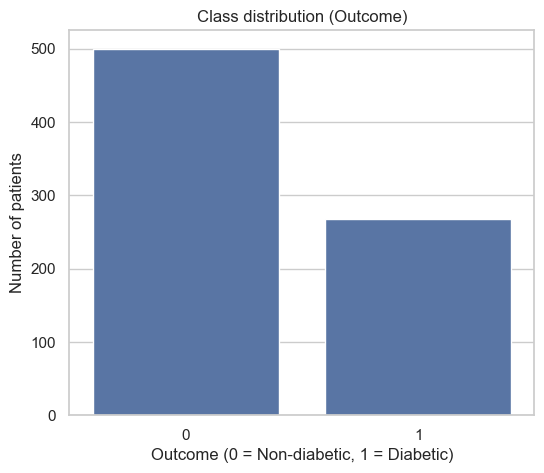

In [20]:
# Visualization of the class distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='Outcome', data=df)
plt.xlabel('Outcome (0 = Non-diabetic, 1 = Diabetic)')
plt.ylabel('Number of patients')
plt.title('Class distribution (Outcome)')
plt.show()


**Conclusion (Class Distribution):**
The dataset is imbalanced: about 65% of patients are non-diabetic (Outcome = 0) versus
35% diabetic (Outcome = 1). This imbalance is important to keep in mind for a potential
future modeling phase (not covered here, since the goal is only EDA).


## 7. Correlation Analysis

We study the relationships between variables using covariance and correlation matrices, then visualize them with a heatmap. This helps identify the variables most related to each other, and in particular those related to `Outcome` (question 7).

In [22]:
# Covariance matrix: shows how variables vary together (scale-dependent)
covariance = df[attributes_Quant].cov()
print("Covariance matrix:")
covariance


Covariance matrix:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,11.354056,13.947131,9.214538,-4.390041,-28.555231,0.469774,-0.037426,21.570620
Glucose,13.947131,1022.248314,94.430956,29.239183,1220.935799,55.726987,1.454875,99.082805
BloodPressure,9.214538,94.430956,374.647271,64.029396,198.378412,43.004695,0.264638,54.523453
SkinThickness,-4.390041,29.239183,64.029396,254.473245,802.979941,49.373869,0.972136,-21.381023
Insulin,-28.555231,1220.935799,198.378412,802.979941,13281.180078,179.775172,7.066681,-57.143290
BMI,0.469774,55.726987,43.004695,49.373869,179.775172,62.159984,0.367405,3.360330
DiabetesPedigreeFunction,-0.037426,1.454875,0.264638,0.972136,7.066681,0.367405,0.109779,0.130772
Age,21.570620,99.082805,54.523453,-21.381023,-57.143290,3.360330,0.130772,138.303046


In [24]:
# Correlation matrix: normalized version (between -1 and 1), easier to interpret
correlation = df[attributes_Quant].corr()
print("Correlation matrix:")
correlation


Correlation matrix:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000


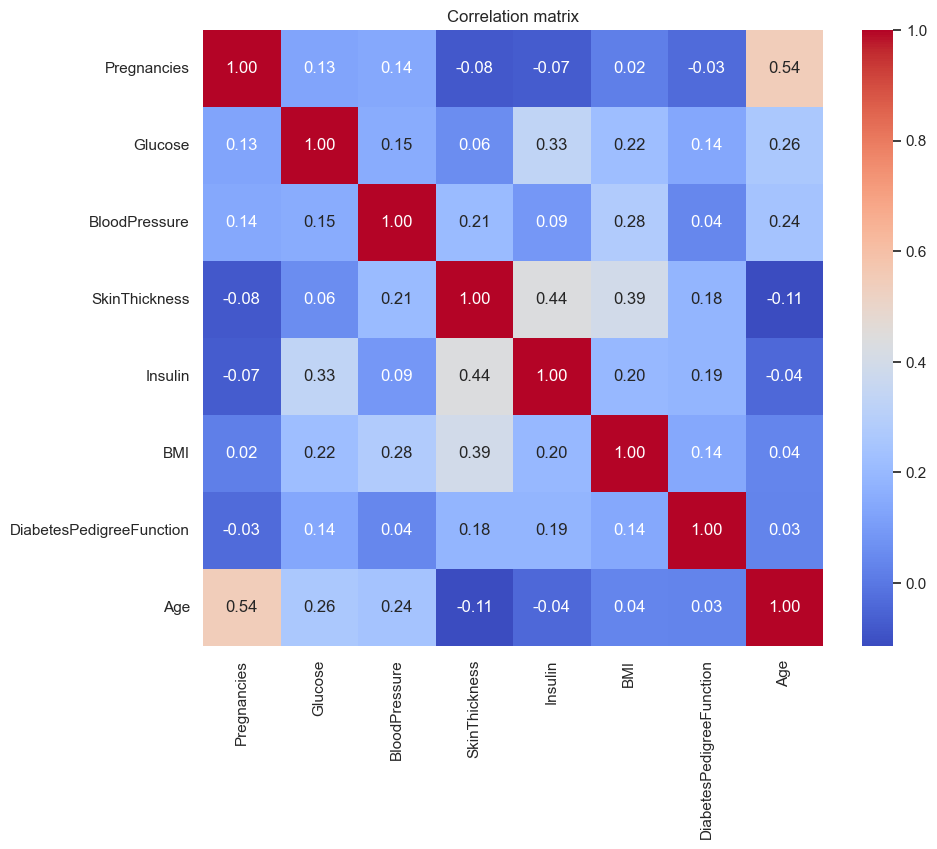

In [26]:
# Visualization of the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()


**Conclusion (Correlation Analysis):**
No pair of explanatory variables is strongly correlated with each other (no major
redundancy), which is rather positive. The variables that appear most related to
each other are Age/Pregnancies and SkinThickness/Insulin, which is consistent from
a physiological standpoint.


## 8. Data Visualization

We visualize the distribution of the variables, the relationships between them and potential outliers, in order to answer questions 3, 5 and 7.

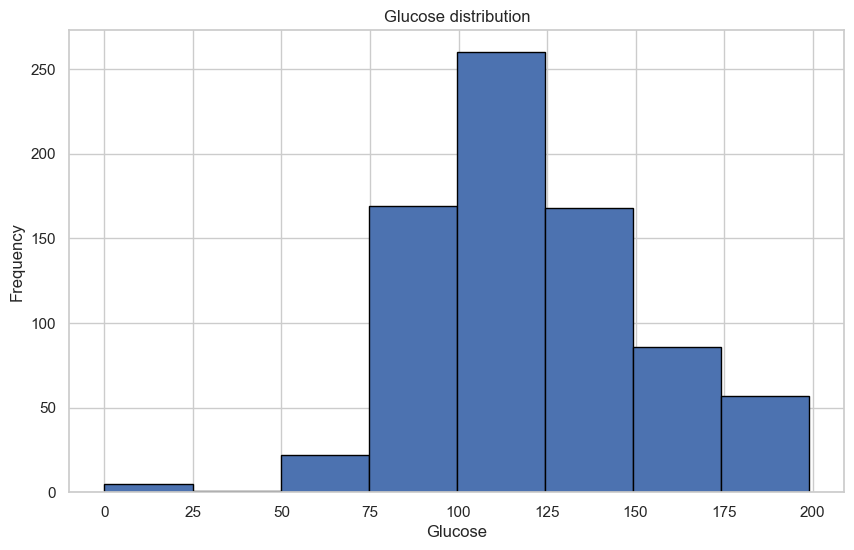

In [28]:
# Distribution of the Glucose variable
plt.figure(figsize=(10, 6))
plt.hist(df['Glucose'], bins=8, edgecolor='black')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.title('Glucose distribution')
plt.show()


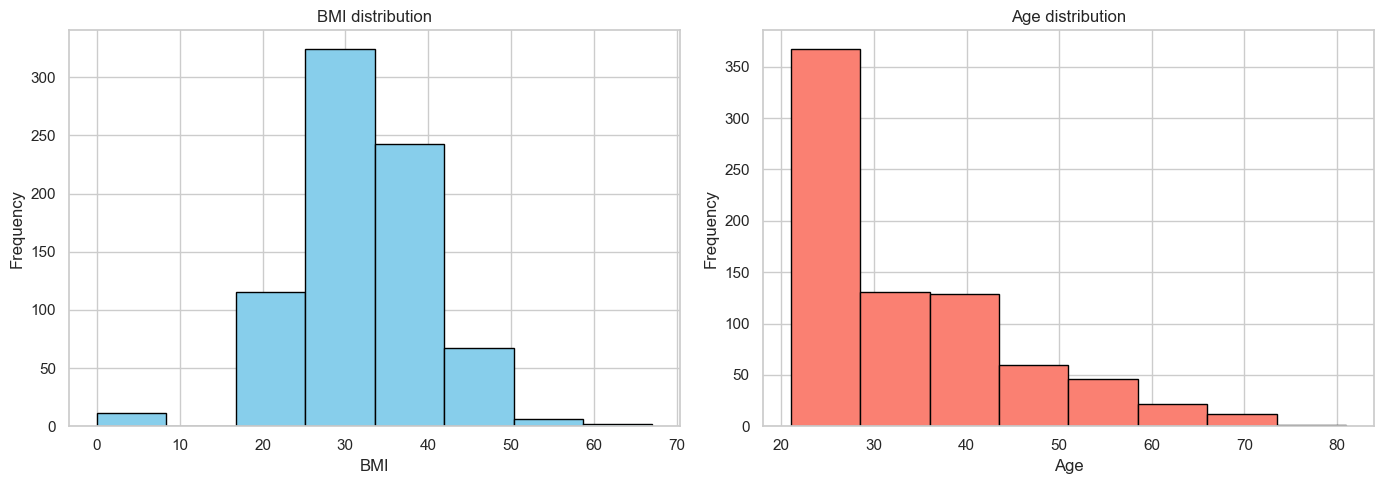

In [30]:
# Distribution of a couple of other key variables (BMI and Age)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['BMI'], bins=8, edgecolor='black', color='skyblue')
axes[0].set_title('BMI distribution')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Age'], bins=8, edgecolor='black', color='salmon')
axes[1].set_title('Age distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


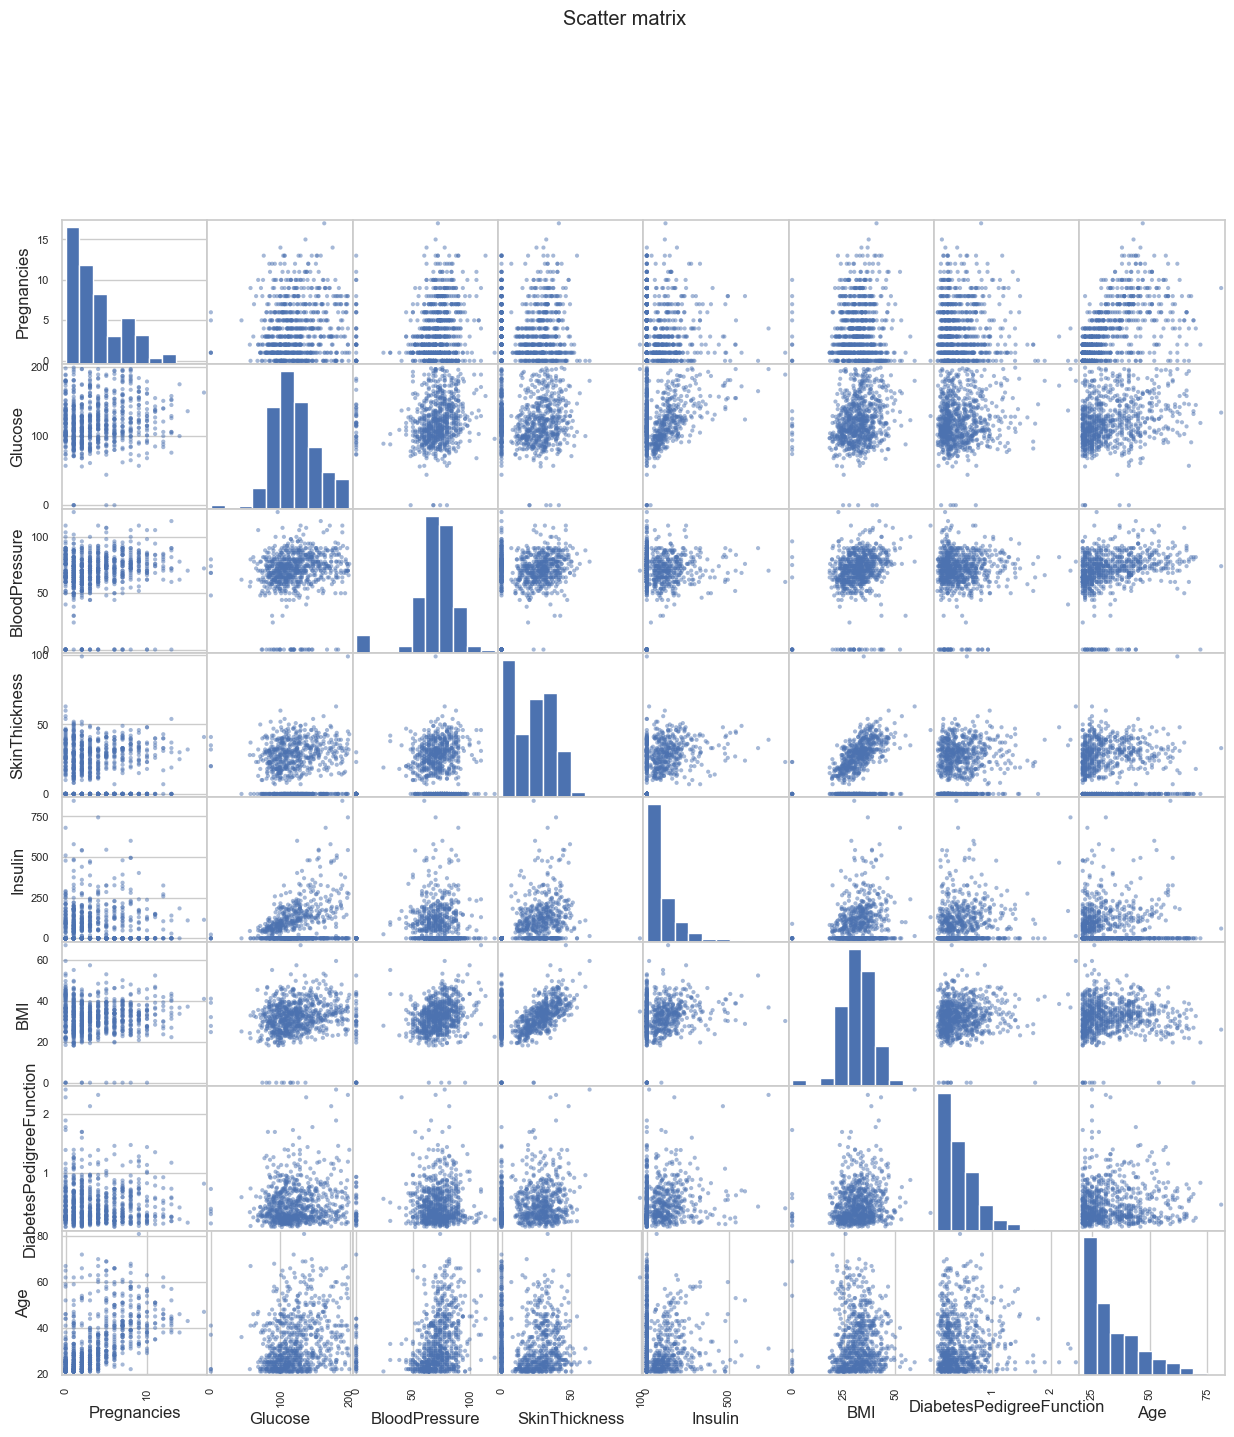

In [32]:
# Scatter matrix: allows visualizing pairwise relationships between variables
fig = scatter_matrix(df[attributes_Quant], figsize=(15, 15), diagonal='hist')
plt.suptitle('Scatter matrix', y=1.02)
plt.show()


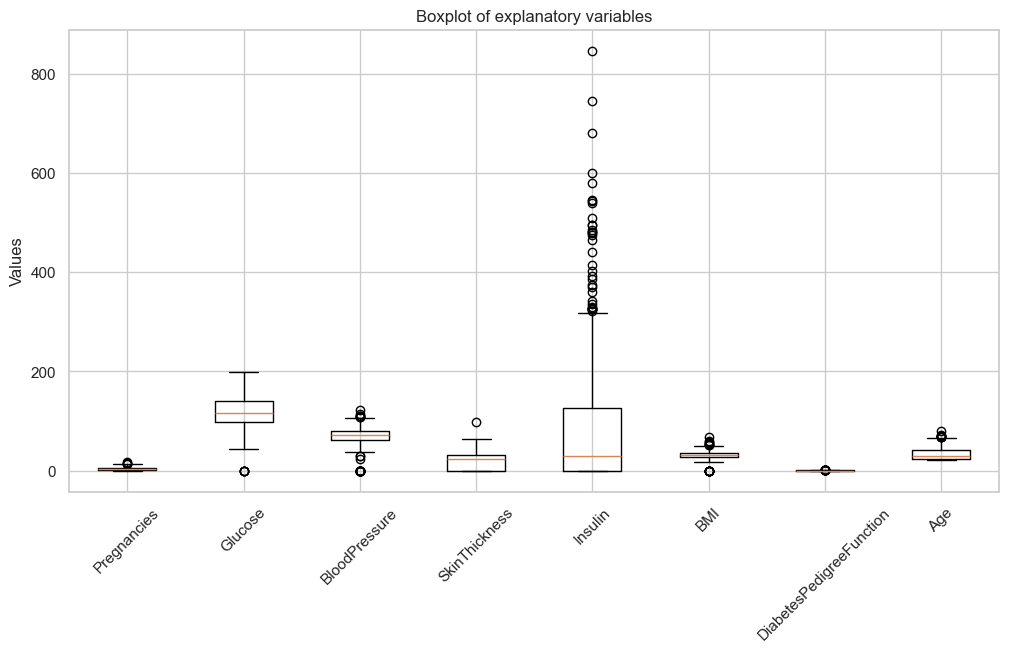

In [34]:
# Overall boxplot of the explanatory variables: useful to visually spot outliers
# (points beyond the whiskers) and scale differences between variables
X = df.drop(columns=['Outcome'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(X.values, labels=X.columns)
ax.set_title("Boxplot of explanatory variables")
ax.set_ylabel("Values")
plt.xticks(rotation=45)
plt.show()


**Conclusion (Data Visualization):**
Glucose and BMI seem to follow a distribution close to normal (with a slight right
skew), while Insulin and SkinThickness show many points beyond the boxplot whiskers,
likely a sign of outliers or missing values coded as 0 (see the Data Quality
Assessment section).


## 9. Hypothesis Testing

We formulate a few simple and intuitive hypotheses, then check them using descriptive statistics and visualizations (groupby, means, boxplots).

### Hypothesis 1

**People with diabetes tend to have higher glucose levels.**


In [36]:
# We compare the mean Glucose value between the two classes (diabetic / non-diabetic)
moyennes_glucose = df.groupby('Outcome')['Glucose'].mean()
print("Mean Glucose per class:")
print(f" Non-diabetic (0): {moyennes_glucose[0]:.2f} mg/dL")
print(f" Diabetic (1)    : {moyennes_glucose[1]:.2f} mg/dL")


Mean Glucose per class:
 Non-diabetic (0): 109.98 mg/dL
 Diabetic (1)    : 141.26 mg/dL


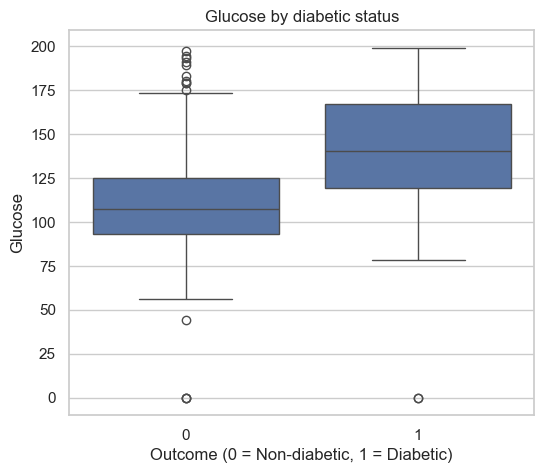

In [38]:
# Boxplot visualization to visually confirm the difference between the two groups
plt.figure(figsize=(6, 5))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.xlabel('Outcome (0 = Non-diabetic, 1 = Diabetic)')
plt.ylabel('Glucose')
plt.title('Glucose by diabetic status')
plt.show()


**Conclusion Hypothesis 1:** The hypothesis is confirmed: the mean glucose level is clearly higher in diabetic patients, which is consistent with the physiology of diabetes.

### Hypothesis 2

**Diabetic patients tend to have a higher BMI.**


In [40]:
# Comparison of mean BMI between the two classes
moyennes_bmi = df.groupby('Outcome')['BMI'].mean()
print("Mean BMI per class:")
print(f" Non-diabetic (0): {moyennes_bmi[0]:.2f}")
print(f" Diabetic (1)    : {moyennes_bmi[1]:.2f}")


Mean BMI per class:
 Non-diabetic (0): 30.30
 Diabetic (1)    : 35.14


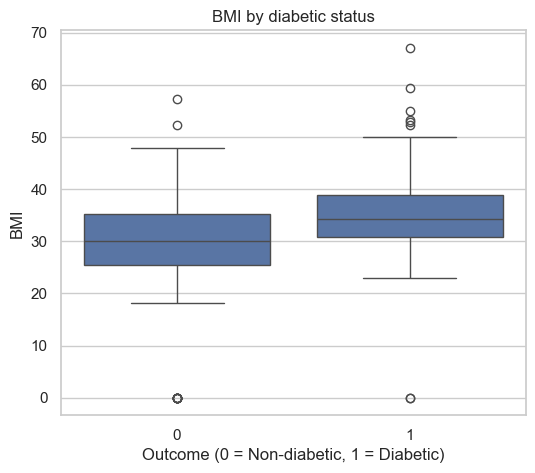

In [42]:
# Boxplot visualization
plt.figure(figsize=(6, 5))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.xlabel('Outcome (0 = Non-diabetic, 1 = Diabetic)')
plt.ylabel('BMI')
plt.title('BMI by diabetic status')
plt.show()


**Conclusion Hypothesis 2:** The hypothesis is confirmed: diabetic patients have on average a higher BMI than non-diabetic ones, suggesting a link between being overweight and diabetes.

### Hypothesis 3

**Older people are more likely to have diabetes.**


In [44]:
# Comparison of mean age between the two classes
moyennes_age = df.groupby('Outcome')['Age'].mean()
print("Mean Age per class:")
print(f" Non-diabetic (0): {moyennes_age[0]:.2f} years")
print(f" Diabetic (1)    : {moyennes_age[1]:.2f} years")


Mean Age per class:
 Non-diabetic (0): 31.19 years
 Diabetic (1)    : 37.07 years


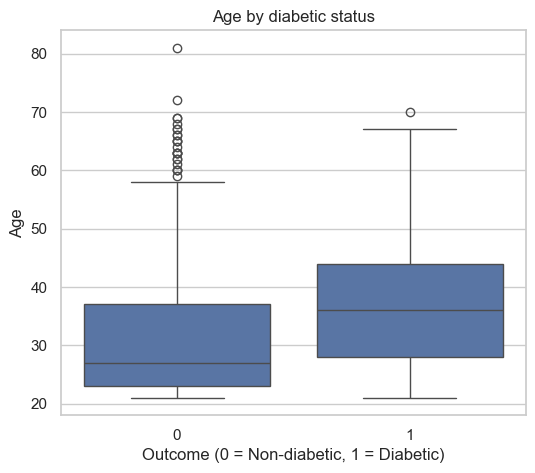

In [46]:
# Boxplot visualization
plt.figure(figsize=(6, 5))
sns.boxplot(x='Outcome', y='Age', data=df)
plt.xlabel('Outcome (0 = Non-diabetic, 1 = Diabetic)')
plt.ylabel('Age')
plt.title('Age by diabetic status')
plt.show()


**Conclusion Hypothesis 3:** The hypothesis is broadly confirmed: diabetic patients are on average older, although the gap is less pronounced than for Glucose or BMI.

## 10. Data Quality Assessment

We look here for potential problems in the data: missing values, duplicates, and suspicious zero values (questions 3, 4, 5, 8).

In [48]:
# Search for missing values (NaN) in each column
print("Number of missing values (NaN) per column:")
df.isnull().sum()


Number of missing values (NaN) per column:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [50]:
# Search for duplicated rows in the dataset
print("Number of duplicated rows:", df.duplicated().sum())


Number of duplicated rows: 0


In [52]:
# Some columns cannot physiologically be equal to 0 (Glucose, BloodPressure, BMI,
# Insulin, SkinThickness). A value of 0 in these columns is therefore likely a missing
# value coded as 0, rather than an actual measurement.
colonnes_suspectes = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Number of values equal to 0 (potentially missing) per column:")
for col in colonnes_suspectes:
    nb_zeros = (df[col] == 0).sum()
    pourcentage = nb_zeros / len(df) * 100
    print(f" {col:15s} : {nb_zeros} zero values ({pourcentage:.1f}%)")


Number of values equal to 0 (potentially missing) per column:
 Glucose         : 5 zero values (0.7%)
 BloodPressure   : 35 zero values (4.6%)
 SkinThickness   : 227 zero values (29.6%)
 Insulin         : 374 zero values (48.7%)
 BMI             : 11 zero values (1.4%)


**Conclusion (Data Quality Assessment):**
The dataset contains neither explicit missing values (NaN) nor duplicates. However,
several columns contain values equal to 0 that make no physiological sense (for
example Insulin and SkinThickness have a significant number of zeros). These zeros
very likely represent missing values coded differently, and will need to be
addressed (e.g. through imputation) before any future modeling step.


## 11. Final Conclusions

### Final EDA Summary

**Observed trends:**
- Glucose, BMI and age are on average higher in diabetic patients.
- The distributions of Glucose and BMI are close to normal, slightly skewed to the right.

**Important correlations:**
- No very strong correlation between explanatory variables (no major redundancy).
- Moderate correlations exist between Age/Pregnancies and between SkinThickness/Insulin.

**Detected anomalies:**
- Presence of extreme values (outliers) on Insulin and SkinThickness, visible in the boxplots.
- High standard deviations on some variables, revealing widely dispersed values.

**Data quality issues:**
- No missing values (NaN) or duplicates.
- Presence of suspicious zero values in Glucose, BloodPressure, SkinThickness, Insulin
  and BMI, which likely represent missing values coded as zero.

**Class imbalance:**
- The dataset is imbalanced (~65% non-diabetic vs ~35% diabetic).

**Interesting points for a potential future Machine Learning phase (not covered here):**
- Handle the suspicious zeros (imputation) before any model training.
- Consider normalizing the variables, since they are not on the same scale.
- Account for the class imbalance (e.g. via resampling or class weighting) in a
  future modeling step.
- Glucose, BMI and Age appear to be potentially discriminative variables for
  predicting diabetes.
